In [9]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [4]:
## Heat budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree, monthly mean
    # Desnity of seawater: 1025 Kg/m3
    # Speciic heat capacity of seawater: 4000 J/Kg/K
    # Assume constant mixed layer temperature

In [3]:
## Open 5 Day means to compute ddelta H acrosss the month

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [4]:
# Compute time series of dH/dT

dt['gridT']['T_MLD_Product'] = dt['gridT']['tos_con'] * dt['gridT']['somxl010']
H_ts = (dt.integral(grid='gridT', var='T_MLD_Product', dims=['i', 'j'])) * 1025 * 4000
delta_H = H_ts.resample(time_counter='ME').map(lambda x: x.isel(time_counter=-1) - x.isel(time_counter=0))
days_in_month = H_ts.resample(time_counter='ME').map(lambda x: x.time_counter[-1].dt.day - x.time_counter[0].dt.day)
seconds_in_month = days_in_month * 24 * 60 * 60
dHbydt = (delta_H / seconds_in_month).compute()


In [5]:
# Open monthly means to compute Q 

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt_monthly = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [16]:
# Compute integrated MLD time series

integrated_MLD = (dt_monthly.integral(grid='gridT', var='somxl010', dims=['i', 'j'])).compute()
new_times = pd.date_range('1990-01', periods=420, freq='ME').values 
integrated_MLD = integrated_MLD.assign_coords(time_counter = new_times)


In [6]:
# Compute the time series of Q 

Q = dt_monthly.integral(grid='gridT', var='hfds', dims=['i', 'j']) 
Q = Q.assign_coords(time_counter=new_times)
Q = Q.compute()

In [38]:
# Save Terms

dHbydt.to_netcdf('dHbydt.nc')
Q.to_netcdf('Q.nc')
integrated_MLD.to_netcdf('integrated_MLD.nc')

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\TomAH\\OneDrive - Nexus365\\4th Year\\FOURTH YEAR PROJECT !!\\All Code\\Hillary\\BUDGET ANALYSIS\\dHbydt.nc'

In [10]:
# Start from here 

dHbydt = xr.open_dataset('dHbydt.nc')['__xarray_dataarray_variable__']
Q = xr.open_dataset('Q.nc')['hfds']
integrated_MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']

In [23]:
dHbydt

<xarray.DataArray '__xarray_dataarray_variable__' (time_counter: 420)> Size: 3kB
[420 values with dtype=float64]
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 3kB 1990-01-31 ... 2024-12-31
Attributes:
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)
    axis:                T
    standard_name:       time
    long_name:           Time axis
    time_origin:         1900-01-01 00:00:00
    bounds:              time_counter_bounds

In [11]:
# Calculate advective term and ratios 

advection = dHbydt - Q
magnitude_ratios = abs(Q) / abs(advection)
heatflux_contribution = Q / dHbydt

(np.float64(9496.0), np.float64(11292.0))

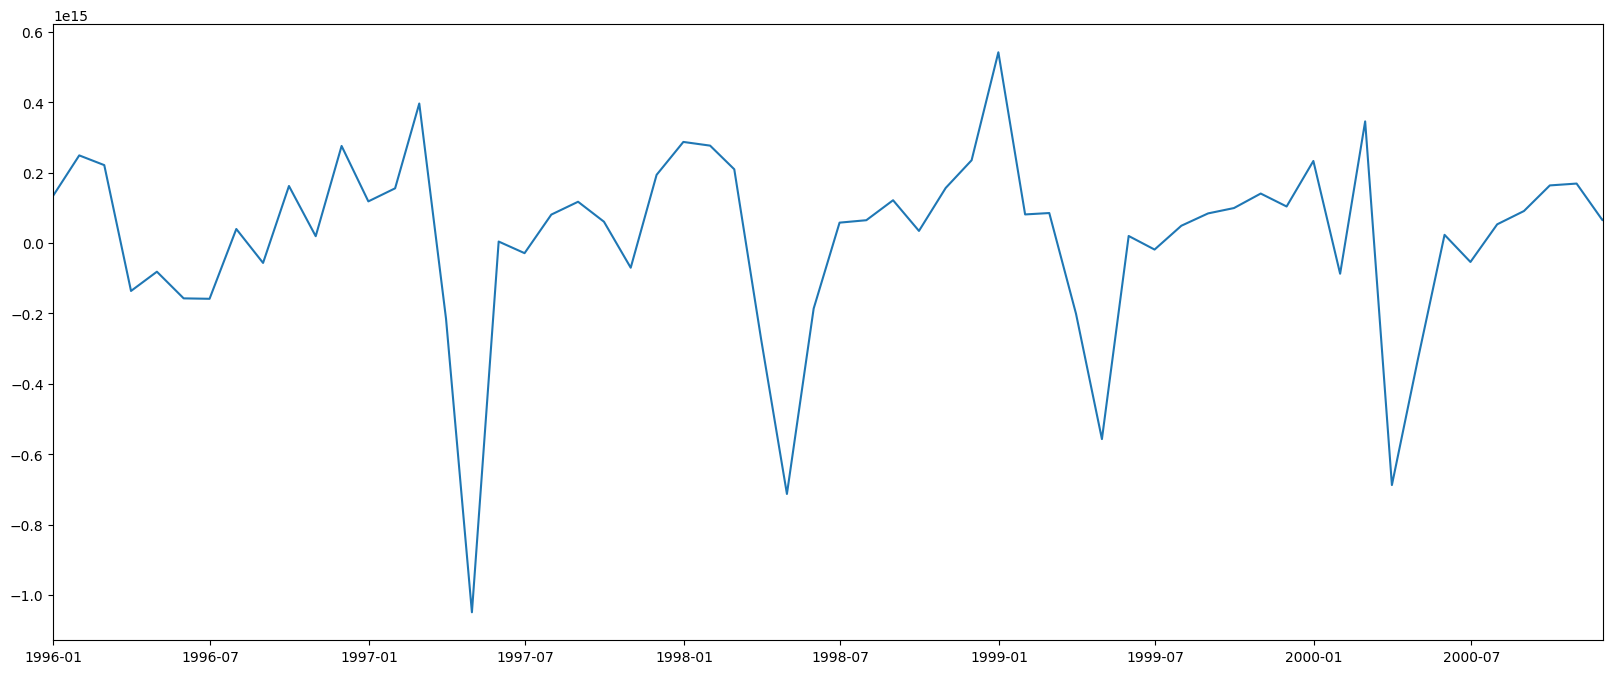

In [12]:
# Change in Heat Content 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(dHbydt['time_counter'], dHbydt)
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

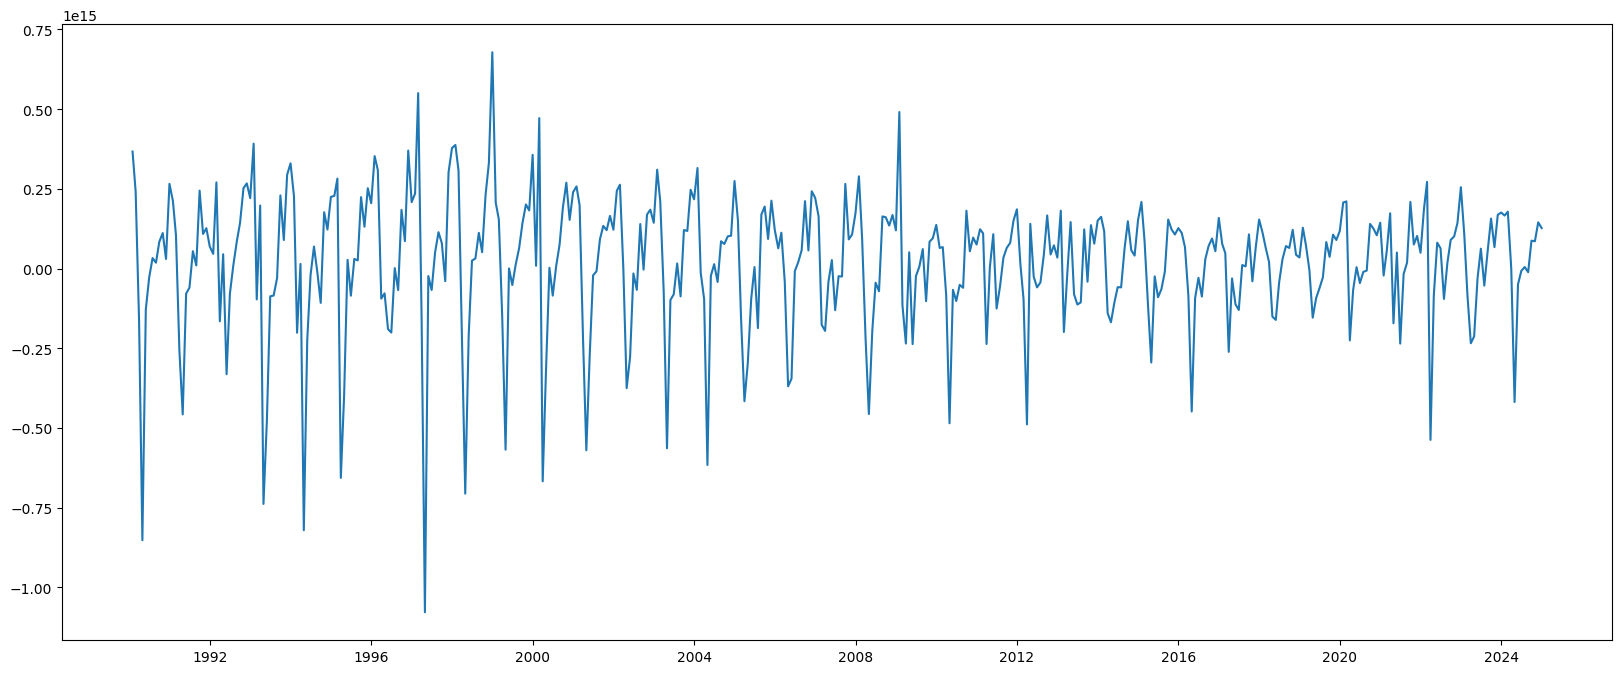

In [13]:
# Plot of advective terms 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(advection['time_counter'], advection)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

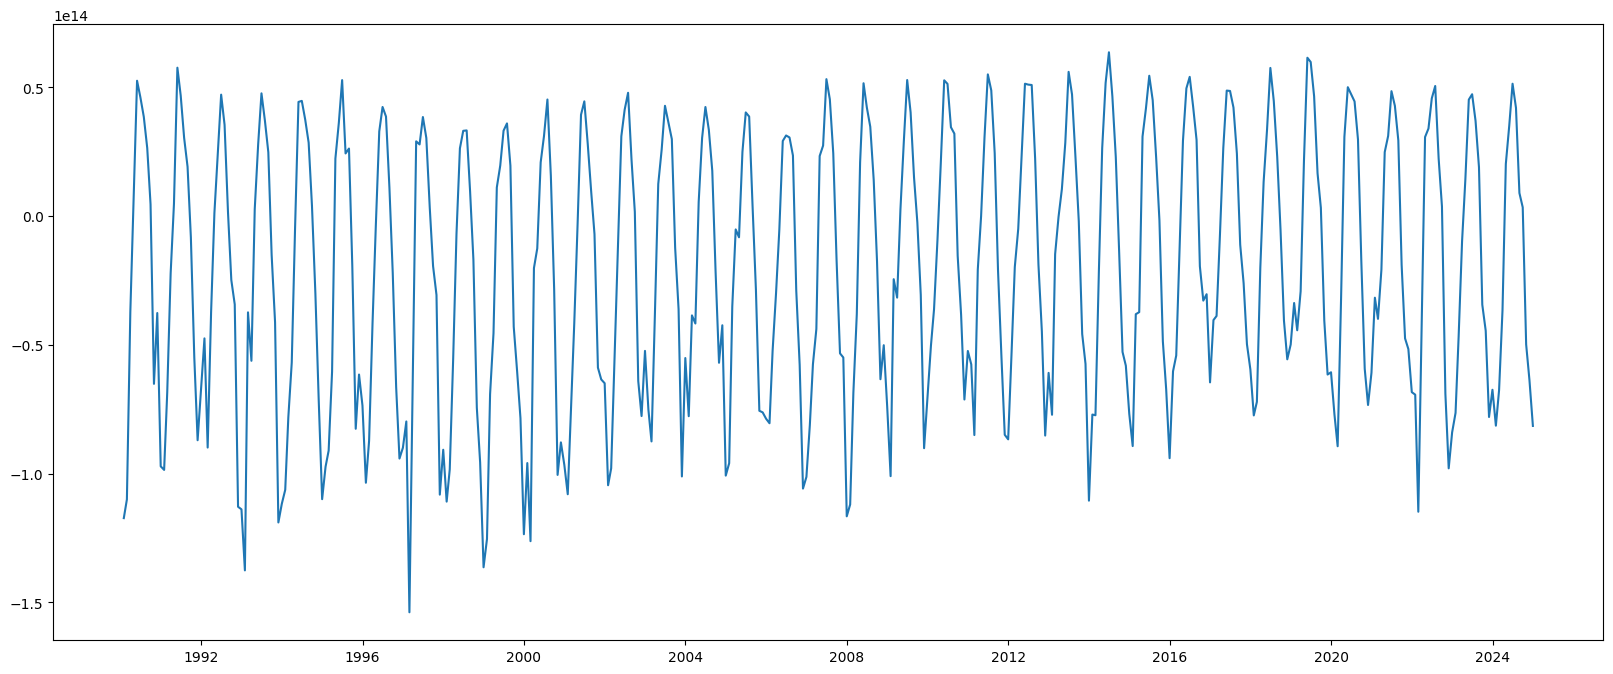

In [14]:
# Surface heat flux terms

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(Q['time_counter'], Q)
#ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

Text(0, 0.5, 'Integrated MLD (m3)')

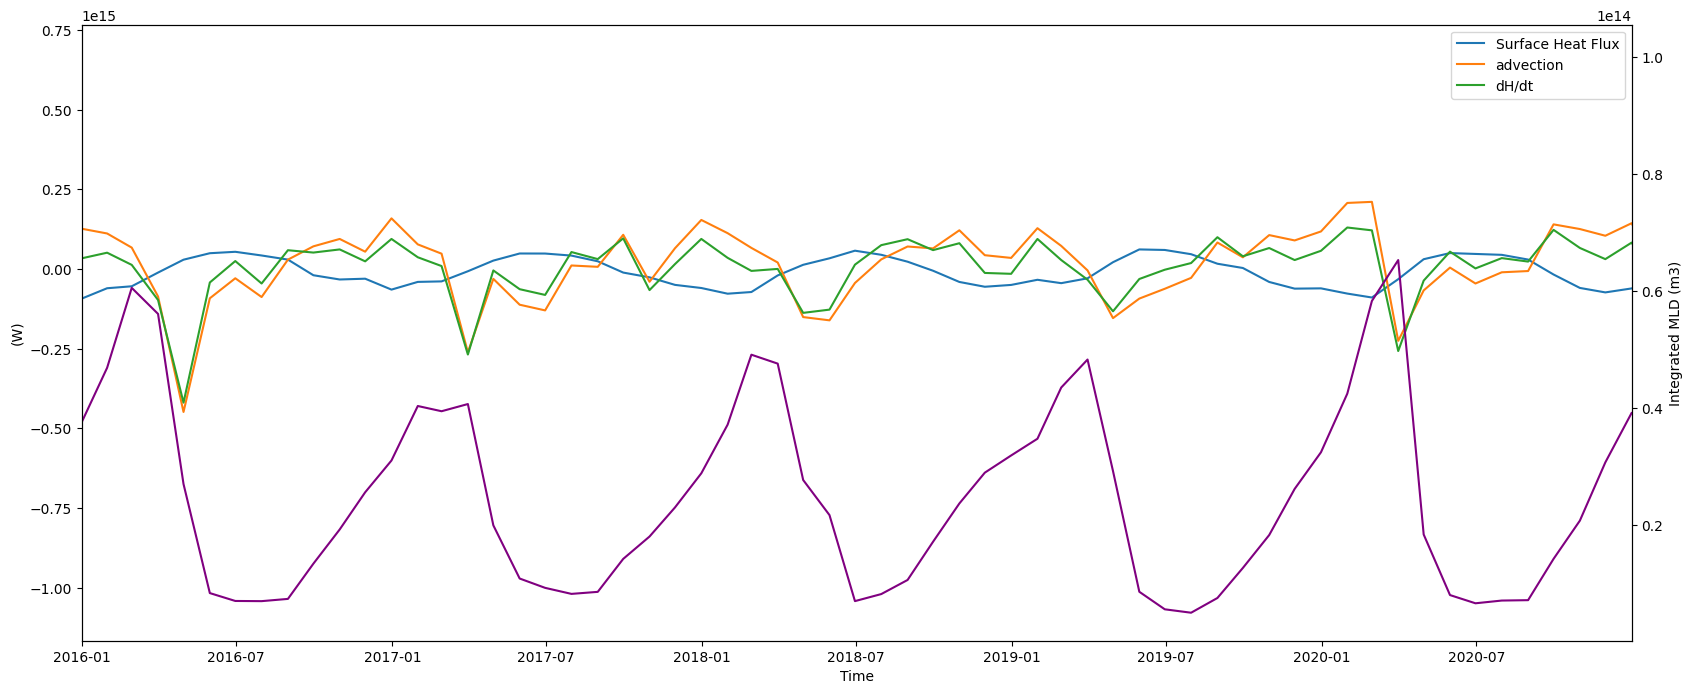

In [21]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))
ax2 = ax.twinx() 

ax.plot(Q['time_counter'], Q, label = 'Surface Heat Flux')
ax.plot(advection['time_counter'], advection, label = 'advection')
ax.plot(dHbydt['time_counter'], dHbydt, label = 'dH/dt')
ax2.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
ax.legend(loc = 'best')
ax.set_xlim(np.datetime64('2016-01-01'), np.datetime64('2020-12-31'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')
ax2.set_ylabel('Integrated MLD (m3)')

(0.0, 5.0)

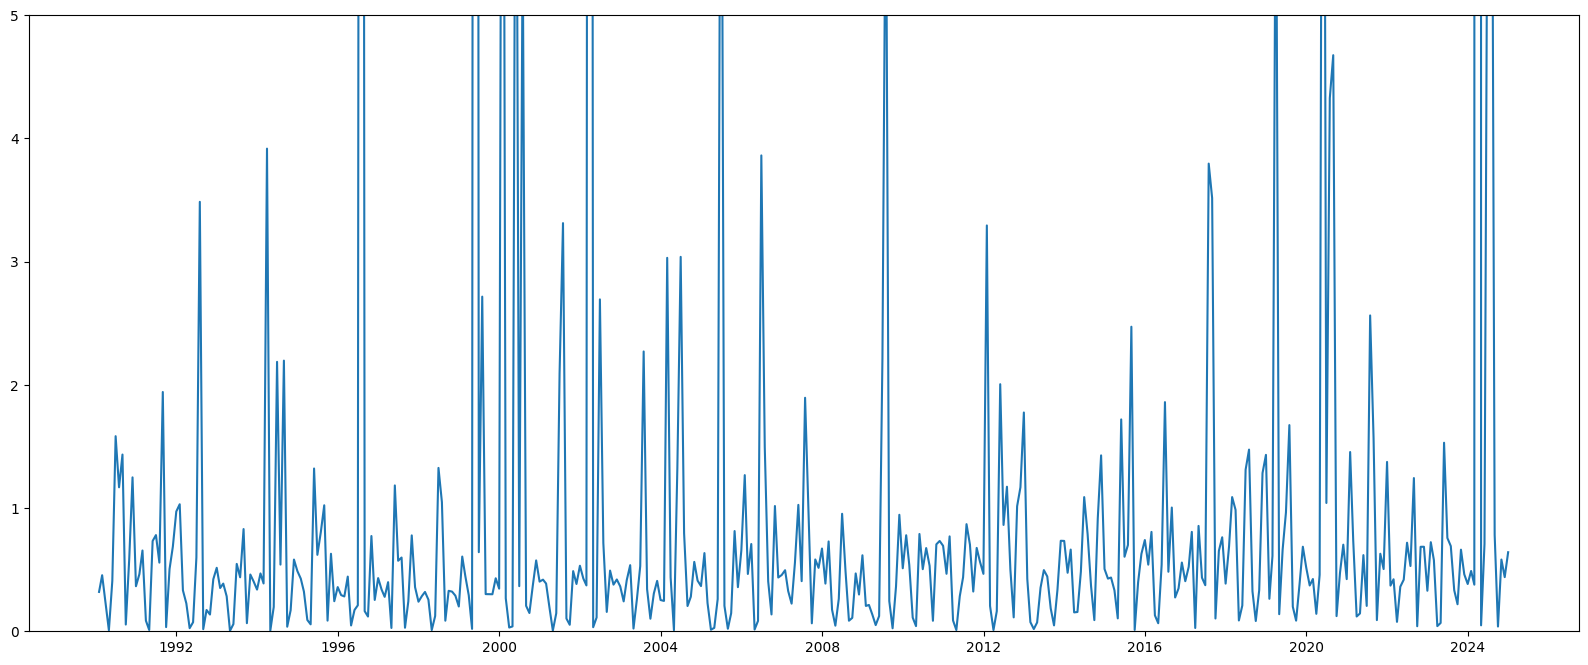

In [16]:
# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios['time_counter'], magnitude_ratios)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)


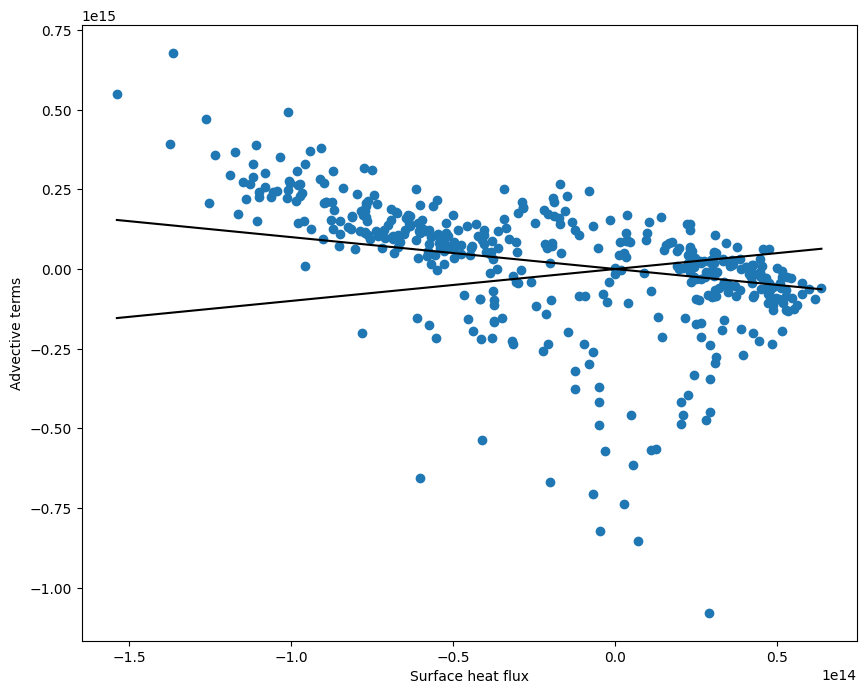

In [18]:
# Josey and Sinha Plot

fig, ax = plt.subplots(figsize = (10, 8))

plt.scatter(Q.values, advection.values)
plt.xlabel('Surface heat flux')
plt.ylabel('Advective terms')

xmin = Q.min().item()
xmax = Q.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
# ax.set_xlim(-1.5e14, 0.7e14)
# ax.set_ylim(-1e14, 1.5e14)

plt.show()

In [51]:
## Now consider Annual Means 

Q_annual = Q.resample(time_counter = 'YE').mean()
advection_annual = advection.resample(time_counter = 'YE').mean()
dHbydt_annual = dHbydt.resample(time_counter = 'YE').mean()

Text(0, 0.5, '(W)')

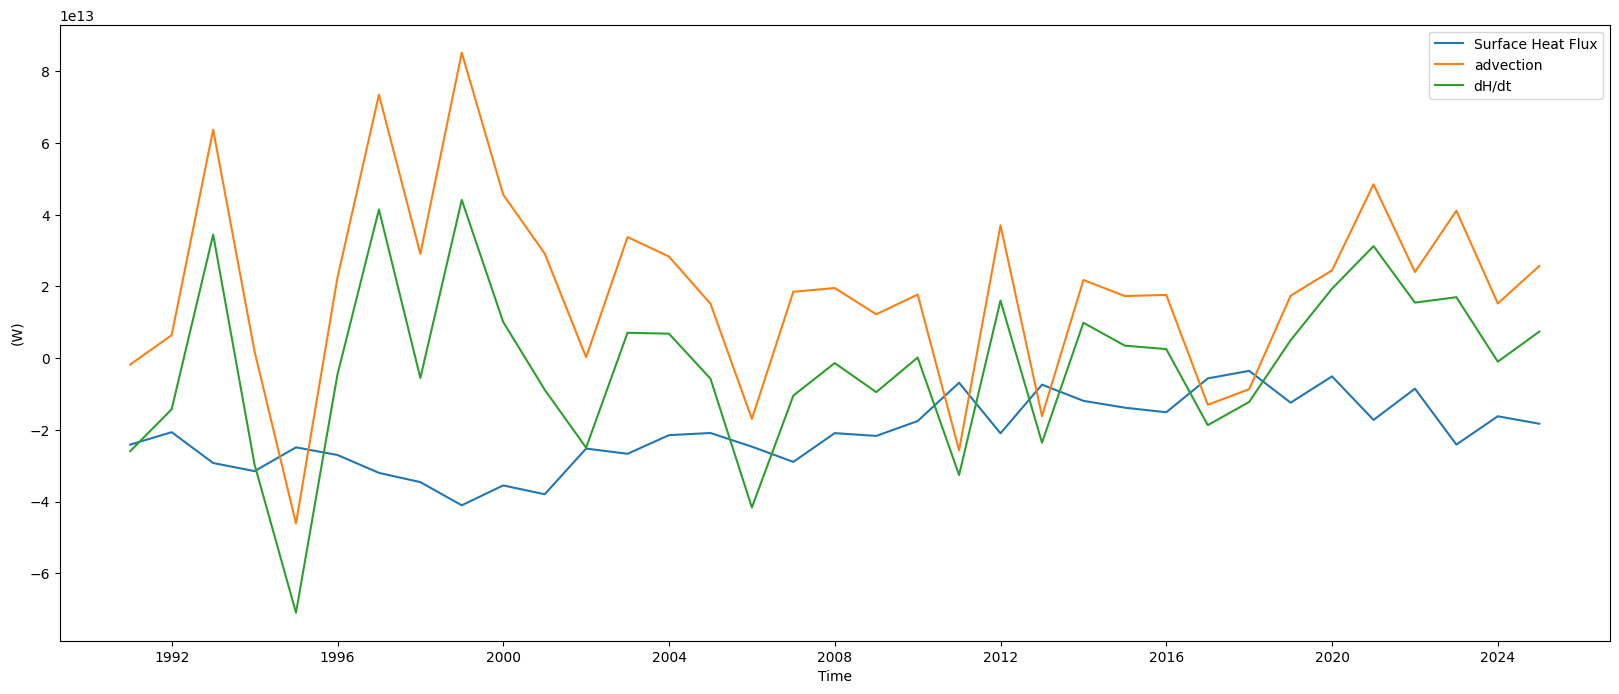

In [52]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))

ax.plot(Q_annual['time_counter'], Q_annual, label = 'Surface Heat Flux')
ax.plot(advection_annual['time_counter'], advection_annual, label = 'advection')
ax.plot(dHbydt_annual['time_counter'], dHbydt_annual, label = 'dH/dt')
ax.legend(loc = 'best')
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')

(0.0, 5.0)

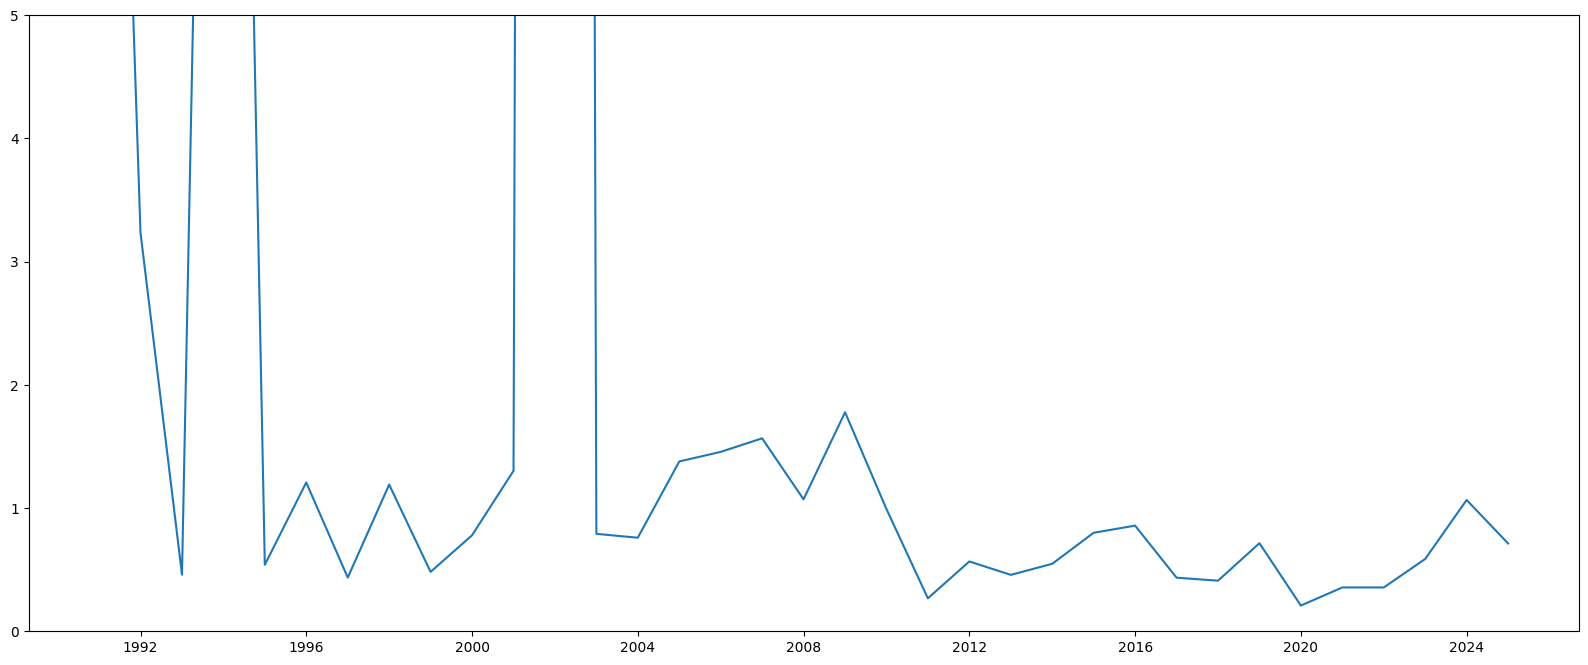

In [57]:
magnitude_ratios_annual = abs(Q_annual) / abs(advection_annual)

# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios_annual['time_counter'], magnitude_ratios_annual)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)
